In [2]:
import os
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [64]:
def preprocess_and_resample(df, freq='64L'):
    if 'time' in df.columns:
        df['time'] = pd.to_datetime(df['time'], unit='s')
        df.set_index('time', inplace=True)
        df_resampled = df.resample(freq).mean()  # Resample to the desired frequency
        return df_resampled
    else:
        return df
    
def preprocess_systolic_peaks(df, freq='64L'):
    if 'peaks' in df.columns:
        df['time'] = pd.to_datetime(df['peaks'], unit='s')
        df.set_index('time', inplace=True)
        df['systolic_peak'] = 1  # Indicate peak presence with 1
        df_resampled = df.resample(freq).asfreq().fillna(0)  # Fill NaNs with 0 to indicate no peak
        df_resampled.reset_index(inplace=True)
        return df_resampled[['time', 'systolic_peak']]
    else:
        return df

In [ ]:
# Assume data_dict contains DataFrames for each modality
resampled_data = {}
for sensor, data_list in data_dict.items():
    if data_list:
        combined_df = pd.concat(data_list)
        if sensor == 'accelerometer':
            resampled_data[sensor] = preprocess_and_resample(combined_df)
        elif sensor == 'bvp':
            resampled_data[sensor] = preprocess_and_resample(combined_df)
        elif sensor == 'eda':
            resampled_data[sensor] = preprocess_and_resample(combined_df, freq='64L')
        elif sensor == 'temperature':
            resampled_data[sensor] = preprocess_and_resample(combined_df, freq='64L')
        elif sensor == 'systolicPeaks':
            resampled_data[sensor] = preprocess_systolic_peaks(combined_df, freq='64L')

# Combine all resampled DataFrames on the 'time' column
combined_df = None
for sensor, df in resampled_data.items():
    if combined_df is None:
        combined_df = df
    else:
        combined_df = combined_df.merge(df, on='time', how='outer')

# Reset index and sort by time
combined_df.reset_index(drop=True, inplace=True)
combined_df.sort_values(by='time', inplace=True)

print(combined_df.head())
print(f"Number of rows in the combined DataFrame: {len(combined_df)}")


In [96]:
folder_path = r'C:\Users\rusha\Desktop\Uni_Freiburg_Notes\MDD\pilot\abstract_images'
sensors = ['accelerometer', 'bvp', 'eda', 'systolicPeaks', 'temperature']
data_dict = {sensor: [] for sensor in sensors}
dataframes = {}
for subject_folder in os.listdir(folder_path):
    subject_path = os.path.join(folder_path, subject_folder)
    if os.path.isdir(subject_path):
        for sensor in sensors:
            file_path = os.path.join(subject_path, f'{sensor}.csv')
            if os.path.isfile(file_path):
                df = pd.read_csv(file_path)
                df['subject'] = subject_folder
                df['sensor'] = sensor
                data_dict[sensor].append(df)
                if sensor not in dataframes:
                    dataframes[sensor] = []
                
                # Append the DataFrame to the list for this sensor
                dataframes[sensor].append(df)

for sensor in dataframes:
    dataframes[sensor] = pd.concat(dataframes[sensor], ignore_index=True)

df_bvp = dataframes.get('bvp', pd.DataFrame())
df_accelerometer = dataframes.get('accelerometer', pd.DataFrame())
df_eda = dataframes.get('eda', pd.DataFrame())
df_temperature = dataframes.get('temperature', pd.DataFrame())
# # Display columns in each DataFrame
# for sensor, df in resampled_data.items():
#     print(f"Columns in {sensor} DataFrame: {df.columns.tolist()}")

# resampled_data = {}
# for sensor, data_list in data_dict.items():
#     if data_list:
#         combined_df = pd.concat(data_list)
#         if sensor == 'accelerometer':
#             resampled_data[sensor] = preprocess_and_resample(combined_df)
#         elif sensor == 'bvp':
#             resampled_data[sensor] = preprocess_and_resample(combined_df)
#         elif sensor == 'eda':
#             resampled_data[sensor] = preprocess_and_resample(combined_df, freq='64L')
#         elif sensor == 'temperature':
#             resampled_data[sensor] = preprocess_and_resample(combined_df, freq='64L')
#         elif sensor == 'systolicPeaks':
#             resampled_data[sensor] = preprocess_systolic_peaks(combined_df, freq='64L')

# # Combine all resampled DataFrames on the 'time' column
# combined_df = None
# for sensor, df in resampled_data.items():
#     if combined_df is None:
#         combined_df = df
#     else:
#         combined_df = combined_df.merge(df, on='time', how='outer')

# # Reset index and sort by time
# combined_df.reset_index(drop=True, inplace=True)
# combined_df.sort_values(by='time', inplace=True)

# print(combined_df.head())
# print(f"Number of rows in the combined DataFrame: {len(combined_df)}")

In [98]:
# Print DataFrames to verify
print("BVP DataFrame:")
print(df_bvp)

print("Accelerometer DataFrame:")
print(df_accelerometer)

print("EDA DataFrame:")
print(df_eda)

print("Temperature DataFrame:")
print(df_temperature)

BVP DataFrame:
         values          time subject sensor
0      0.119549  1.711102e+09       1    bvp
1      0.125229  1.711102e+09       1    bvp
2      0.130284  1.711102e+09       1    bvp
3      0.134755  1.711102e+09       1    bvp
4      0.138682  1.711102e+09       1    bvp
...         ...           ...     ...    ...
18491  0.009307  1.711124e+09       3    bvp
18492  0.009242  1.711124e+09       3    bvp
18493  0.008992  1.711124e+09       3    bvp
18494  0.008519  1.711124e+09       3    bvp
18495  0.007787  1.711124e+09       3    bvp

[18496 rows x 4 columns]
Accelerometer DataFrame:
           x       y       z          time subject         sensor
0      -27.0   933.0  1819.0  1.711102e+09       1  accelerometer
1       25.0   957.0  1811.0  1.711102e+09       1  accelerometer
2       33.0   958.0  1814.0  1.711102e+09       1  accelerometer
3       44.0   995.0  1825.0  1.711102e+09       1  accelerometer
4        1.0  1020.0  1804.0  1.711102e+09       1  acceleromete

In [50]:
# Combine the data from different sensors
combined_df = pd.DataFrame({'time': resampled_data['accelerometer']['time']})

for sensor in ['accelerometer', 'bvp', 'eda', 'temperature']:
    df = resampled_data[sensor]
    combined_df = combined_df.merge(df, on='time', suffixes=('', f'_{sensor}'))


In [59]:
combined_df

,time,x,y,z,values,values_eda,values_temperature
0,2024-03-22 10:01:26,-23.953125,991.234375,1789.859375,0.021777,-0.013429,30.226562
1,2024-03-22 10:01:27,-15.703125,968.765625,1801.437500,-0.006679,-0.013429,30.226562
2,2024-03-22 10:01:28,-14.984375,938.265625,1820.156250,0.014404,-0.013361,30.226562
3,2024-03-22 10:01:29,-95.687500,688.281250,1916.625000,-0.025050,-0.011858,30.226562
4,2024-03-22 10:01:30,-269.390625,520.390625,1921.765625,0.006386,-0.011644,30.226562
...,...,...,...,...,...,...,...
284,2024-03-22 16:13:13,409.171875,1992.437500,-143.968750,-0.003804,0.490032,31.492188
285,2024-03-22 16:13:14,409.015625,1993.765625,-161.859375,0.007947,0.487753,31.500000
286,2024-03-22 16:13:15,407.250000,1995.203125,-146.546875,-0.003656,0.481915,31.492188
287,2024-03-22 16:13:16,406.734375,1993.546875,-137.562500,-0.007450,0.476915,31.500000


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Perform ANOVA
anova_results = {}
for sensor, df in resampled_data.items():
    if 'time' in df.columns:
        # For simplicity, assuming 'time' is continuous and 'subject' is the categorical variable
        # Convert 'time' to numeric if it's not
        df['time_numeric'] = df['time'].astype('int64')  # Ensure 'time' is numeric
        model = smf.ols('time_numeric ~ C(subject)', data=df).fit()  # Simple ANOVA model
        anova_table = sm.stats.anova_lm(model, typ=2)  # ANOVA table
        anova_results[sensor] = anova_table
    else:
        # Handle cases without 'time' column if needed
        anova_results[sensor] = "No 'time' column for ANOVA"

# Print ANOVA results
for sensor, result in anova_results.items():
    print(f"ANOVA results for sensor: {sensor}")
    print(result)
    print("\n")


In [56]:
print(df['subject'].unique())
print(df.shape)

KeyError: 'subject'

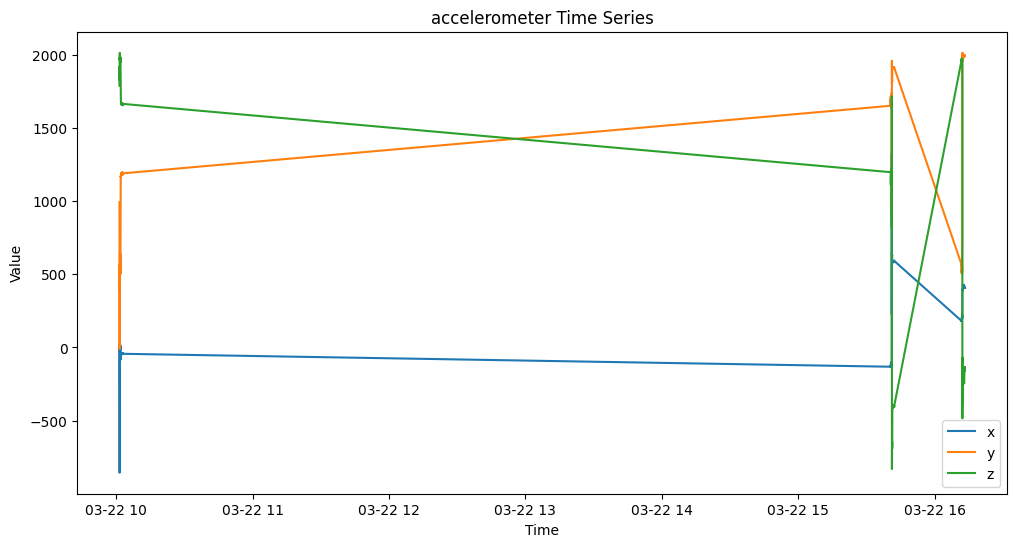

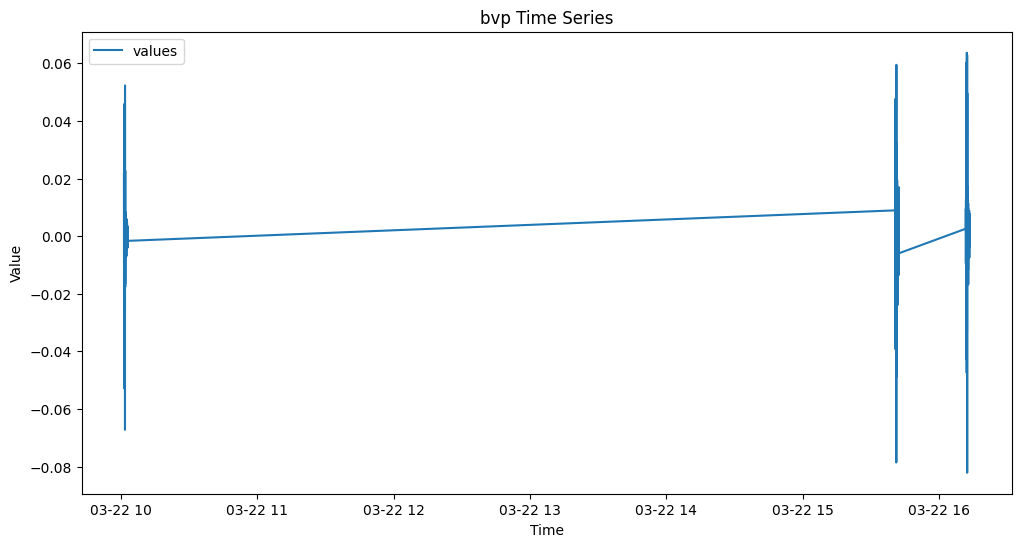

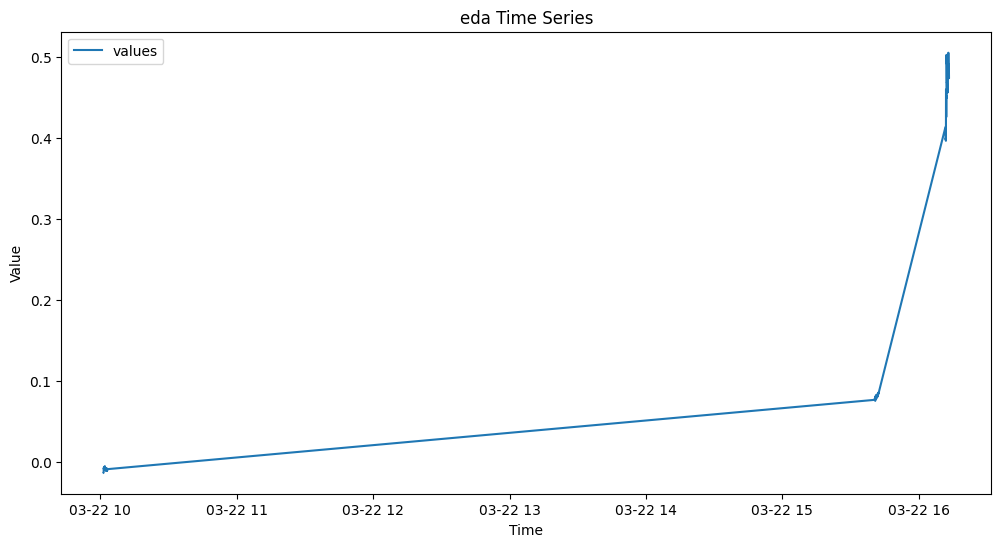

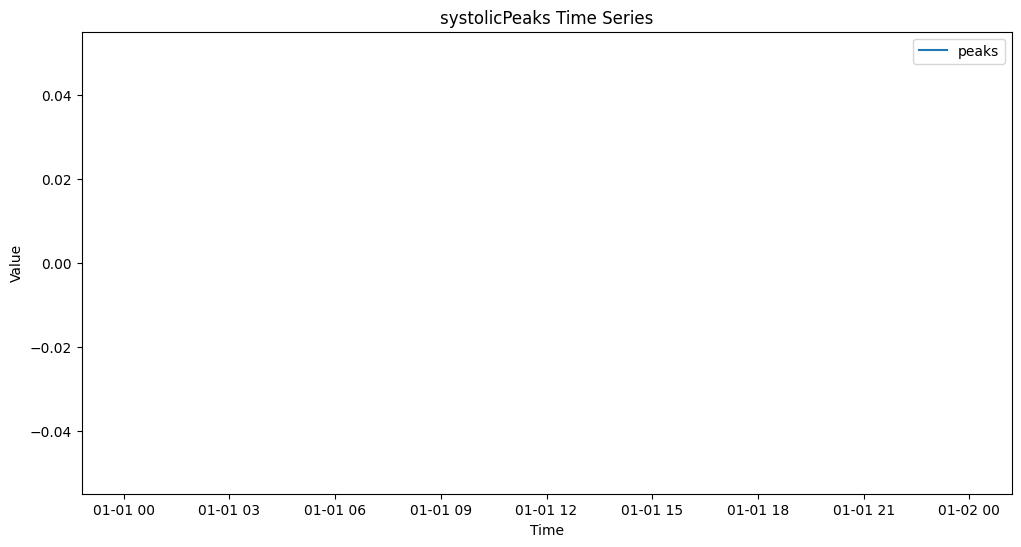

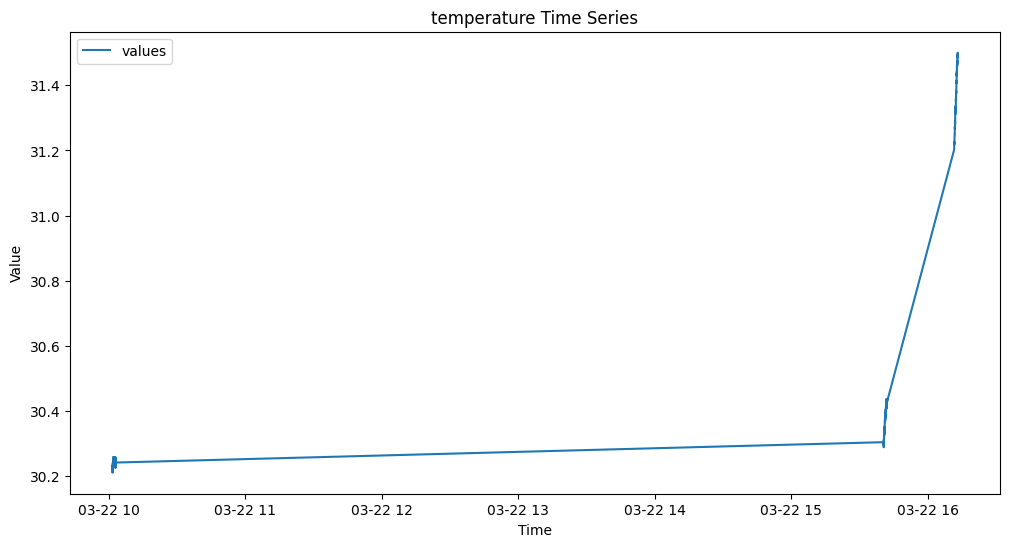

In [45]:
import matplotlib.pyplot as plt
for sensor, df in resampled_data.items():
    plt.figure(figsize=(12, 6))
    for column in df.columns:
        if column != 'time' and column != 'subject' and column != 'sensor':
            plt.plot(df['time'], df[column], label=column)
    plt.title(f'{sensor} Time Series')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [46]:
for sensor, df in resampled_data.items():
    if sensor != 'systolicPeaks' and sensor != 'tags':
        resampled_data[sensor] = df[(df.index >= start_time) & (df.index <= end_time)]

# Align data based on timestamps
aligned_data = pd.concat([df for sensor, df in resampled_data.items() if sensor != 'systolicPeaks' and sensor != 'tags'], axis=1)

# Handle missing data by forward filling and back filling
aligned_data.ffill(inplace=True)
aligned_data.bfill(inplace=True)

# Reset index to get time column back for ANOVA analysis
aligned_data.reset_index(inplace=True)

# Perform ANOVA analysis
anova_results = {}
for column in aligned_data.columns:
    if column not in ['time', 'subject']:
        model = ols(f'{column} ~ C(subject)', data=aligned_data).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        anova_results[column] = anova_table

# Print ANOVA results
for feature, result in anova_results.items():
    print(f"ANOVA results for feature: {feature}")
    print(result)
    print("\n")

NameError: name 'start_time' is not defined